In [1]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import Sequential, layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping 

In [2]:
x = tf.random.normal((100000, 30))
y = tf.random.uniform((100000,1), minval=0, maxval=3, dtype=tf.int32)

I0000 00:00:1790257081.845383      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790257081.847681      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
print(x.shape)
print(y.shape)
print()
print(x)
print()
print(y)

(100000, 30)
(100000, 1)

tf.Tensor(
[[ 0.54192     0.8534371  -1.1586168  ...  0.859998   -1.3074821
  -0.1962652 ]
 [-1.0427855  -2.3576899  -1.0172968  ... -1.1771562   0.09299786
  -1.7058961 ]
 [-2.56471    -0.40813357  0.5255461  ...  0.8910408   1.9333119
  -0.06942889]
 ...
 [-0.65498745 -1.8465848  -0.32668445 ...  0.727201   -0.00412474
  -0.8252619 ]
 [ 0.20965903  0.13780427  0.0384241  ...  0.19614592  0.17914942
  -0.45357472]
 [ 2.4018903   0.91797566 -1.246413   ...  0.8425374   0.4158231
   0.0159223 ]], shape=(100000, 30), dtype=float32)

tf.Tensor(
[[1]
 [1]
 [1]
 ...
 [1]
 [2]
 [2]], shape=(100000, 1), dtype=int32)


In [4]:
x = np.array(x).astype('float32') / 255
y = np.array(y)

In [5]:
from sklearn.model_selection import train_test_split as ttt

In [6]:
x_train, x_test, y_train, y_test = ttt(x,y, random_state=42, test_size=0.3)

print(x_train.shape)
print(x_test.shape)

(70000, 30)
(30000, 30)


In [7]:
temp = pd.Series(y_train[:,0])
np.sort(temp.unique())

array([0, 1, 2], dtype=int32)

In [8]:
import optuna

In [ ]:
def my_model(trial):
    lr = trial.suggest_float('lr', 1e-8, 1e-2, log=True)
    n_layers = trial.suggest_int('n_layers', 1,15)
    
    


    model = keras.Sequential([
        keras.Input(shape=(30,))
    ])

    for i in range(n_layers):
        neurons = trial.suggest_int(f'neurons_{i}', 1,200, step=16)
        activation_fn = trial.suggest_categorical(f'activation_fn_{i}', ['relu', 'leaky_relu', 'elu', 'tanh'])
        initializer = trial.suggest_categorical(f'initializer_{i}', ['he_normal', 'glorot_normal'])
        dropouts = trial.suggest_float(f'dropouts_{i}', 0.0, 0.4, step=0.1)

        regularizer = trial.suggest_categorical(f'regularizer_{i}', ['l1','l2'])
        reg_rate = trial.suggest_float(f'reg_rate_{i}', 1e-8, 1e-2, log=True)
        if regularizer == 'l1':
            chosen_regularizer = regularizers.l1(reg_rate)
        else:
            chosen_regularizer = regularizers.l2(reg_rate)



        
        model.add(layers.Dense(neurons, activation=activation_fn, kernel_initializer=initializer, kernel_regularizer=chosen_regularizer))



        
        if dropouts > 0.0:
            model.add(layers.Dropout(dropouts))

    
    # output layer
    model.add(layers.Dense(4, activation='softmax'))



    
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop', 'nadam'])
    
    if optimizer_name == 'adam':
        chosen_optimizer = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == 'sgd':
        momentum = trial.suggest_float('momentum', 0.1,0.7, step=0.1)
        chosen_optimizer = keras.optimizers.SGD(learning_rate=lr, momentum=momentum) 
    elif optimizer_name == 'rmsprop':
        chosen_optimizer = keras.optimizers.RMSprop(learning_rate=lr)
    else:
        chosen_optimizer = keras.optimizers.Nadam(learning_rate=lr)


    

    model.compile(
        loss = keras.losses.SparseCategoricalCrossentropy(),
        optimizer = chosen_optimizer,
        metrics = ['accuracy']
    )

    early_stop = EarlyStopping(
        patience = 3,
        monitor = 'val_loss',
        restore_best_weights = True,
        verbose = 1
    )
    
    history = model.fit(
        x_train, y_train,
        callbacks = [early_stop],
        verbose = 1,
        epochs = 10,
        validation_split = 0.2,
        batch_size = 128
    )


    trial.set_user_attr('training_loss', history.history['loss'])
    trial.set_user_attr('training_accuracy', history.history['accuracy'])
    trial.set_user_attr('validation_loss', history.history['val_loss'])
    trial.set_user_attr('validation_accuracy', history.history['val_accuracy'])


    model.save(f"model_trial_{trial.number}.keras")

    best_accuracy = max(history.history['val_accuracy'])

    return best_accuracy
    

In [21]:
study = optuna.create_study(direction='maximize')
study.optimize(my_model, n_trials=5)

[I 2026-09-24 13:41:26,966] A new study created in memory with name: no-name-ddbd7eed-9e9b-4f56-829b-9103f77c0d62
/tmp/ipykernel_58/2881224176.py:13: UserWarning: The distribution is specified by [1, 200] and step=16, but the range is not divisible by `step`. It will be replaced with [1, 193].
  neurons = trial.suggest_int(f'neurons_{i}', 1,200, step=16)


Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.2268 - loss: 13.3028 - val_accuracy: 0.3068 - val_loss: 13.2922
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2584 - loss: 13.2893 - val_accuracy: 0.3292 - val_loss: 13.2793
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2848 - loss: 13.2757 - val_accuracy: 0.3288 - val_loss: 13.2665
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3037 - loss: 13.2625 - val_accuracy: 0.3321 - val_loss: 13.2538
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3149 - loss: 13.2493 - val_accuracy: 0.3326 - val_loss: 13.2411
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3238 - loss: 13.2362 - val_accuracy: 0.3331 - val_loss: 13.2283
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3268 - loss: 13.2232 - val_accuracy: 0.3331 - val_loss: 13.2155
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3320 - loss: 13.2097 -

[I 2026-09-24 13:42:13,278] Trial 0 finished with value: 0.33314284682273865 and parameters: {'lr': 1.9681389747458155e-07, 'n_layers': 13, 'neurons_0': 145, 'activation_fn_0': 'tanh', 'initializer_0': 'he_normal', 'dropouts_0': 0.30000000000000004, 'regularizer_0': 'l1', 'reg_rate_0': 0.005528645388268714, 'neurons_1': 145, 'activation_fn_1': 'leaky_relu', 'initializer_1': 'he_normal', 'dropouts_1': 0.30000000000000004, 'regularizer_1': 'l2', 'reg_rate_1': 3.6007687470289583e-08, 'neurons_2': 33, 'activation_fn_2': 'elu', 'initializer_2': 'glorot_normal', 'dropouts_2': 0.1, 'regularizer_2': 'l1', 'reg_rate_2': 1.2822295479796513e-06, 'neurons_3': 49, 'activation_fn_3': 'elu', 'initializer_3': 'glorot_normal', 'dropouts_3': 0.4, 'regularizer_3': 'l2', 'reg_rate_3': 0.0009031620459857533, 'neurons_4': 33, 'activation_fn_4': 'relu', 'initializer_4': 'glorot_normal', 'dropouts_4': 0.1, 'regularizer_4': 'l2', 'reg_rate_4': 1.4680039690041891e-08, 'neurons_5': 129, 'activation_fn_5': 'tanh'

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.3188 - loss: 4.0614 - val_accuracy: 0.3307 - val_loss: 4.0258
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3351 - loss: 3.9873 - val_accuracy: 0.3307 - val_loss: 3.9350
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3323 - loss: 3.8912 - val_accuracy: 0.3307 - val_loss: 3.8187
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3352 - loss: 3.8019 - val_accuracy: 0.3307 - val_loss: 3.7294
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3350 - loss: 3.7454 - val_accuracy: 0.3307 - val_loss: 3.6746
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3324 - loss: 3.7041 - val_accuracy: 0.3307 - val_loss: 3.6340
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3323 - loss: 3.6650 - val_accuracy: 0.3307 - val_loss: 3.5974
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3331 - loss: 3.6296 - val_accuracy: 

[I 2026-09-24 13:42:57,704] Trial 1 finished with value: 0.33071428537368774 and parameters: {'lr': 2.158390088647474e-06, 'n_layers': 13, 'neurons_0': 33, 'activation_fn_0': 'elu', 'initializer_0': 'he_normal', 'dropouts_0': 0.0, 'regularizer_0': 'l2', 'reg_rate_0': 0.0008281479732869979, 'neurons_1': 65, 'activation_fn_1': 'leaky_relu', 'initializer_1': 'glorot_normal', 'dropouts_1': 0.30000000000000004, 'regularizer_1': 'l1', 'reg_rate_1': 9.56882046416446e-08, 'neurons_2': 193, 'activation_fn_2': 'tanh', 'initializer_2': 'glorot_normal', 'dropouts_2': 0.4, 'regularizer_2': 'l1', 'reg_rate_2': 0.00017198120294934424, 'neurons_3': 129, 'activation_fn_3': 'relu', 'initializer_3': 'glorot_normal', 'dropouts_3': 0.2, 'regularizer_3': 'l1', 'reg_rate_3': 6.951373004011294e-08, 'neurons_4': 33, 'activation_fn_4': 'relu', 'initializer_4': 'he_normal', 'dropouts_4': 0.30000000000000004, 'regularizer_4': 'l2', 'reg_rate_4': 1.7262692532059019e-07, 'neurons_5': 17, 'activation_fn_5': 'tanh', 

...

[I 2026-09-24 13:43:11,038] Trial 2 finished with value: 0.3361428678035736 and parameters: {'lr': 0.003565238350346592, 'n_layers': 2, 'neurons_0': 161, 'activation_fn_0': 'relu', 'initializer_0': 'he_normal', 'dropouts_0': 0.0, 'regularizer_0': 'l1', 'reg_rate_0': 4.4035274744929245e-08, 'neurons_1': 81, 'activation_fn_1': 'tanh', 'initializer_1': 'he_normal', 'dropouts_1': 0.30000000000000004, 'regularizer_1': 'l2', 'reg_rate_1': 0.003051130900413476, 'optimizer': 'adam'}. Best is trial 2 with value: 0.3361428678035736.


Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.3362 - loss: 1.8078 - val_accuracy: 0.3307 - val_loss: 1.1205
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3360 - loss: 1.1204 - val_accuracy: 0.3307 - val_loss: 1.1206
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3348 - loss: 1.1195 - val_accuracy: 0.3307 - val_loss: 1.1184
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3357 - loss: 1.1190 - val_accuracy: 0.3307 - val_loss: 1.1195
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3344 - loss: 1.1186 - val_accuracy: 0.3331 - val_loss: 1.1255
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3331 - loss: 1.1185 - val_accuracy: 0.3361 - val_loss: 1.1175
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3343 - loss: 1.1181 - val_accuracy: 0.3307 - val_loss: 1.1180
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3326 - loss: 1.1180 - val_accuracy: 

[I 2026-09-24 13:43:53,302] Trial 3 finished with value: 0.3361428678035736 and parameters: {'lr': 0.0006308415666463943, 'n_layers': 14, 'neurons_0': 65, 'activation_fn_0': 'leaky_relu', 'initializer_0': 'glorot_normal', 'dropouts_0': 0.2, 'regularizer_0': 'l2', 'reg_rate_0': 1.3744649965320126e-08, 'neurons_1': 161, 'activation_fn_1': 'elu', 'initializer_1': 'he_normal', 'dropouts_1': 0.30000000000000004, 'regularizer_1': 'l2', 'reg_rate_1': 5.372797610839647e-07, 'neurons_2': 161, 'activation_fn_2': 'tanh', 'initializer_2': 'glorot_normal', 'dropouts_2': 0.4, 'regularizer_2': 'l1', 'reg_rate_2': 8.213065404158041e-08, 'neurons_3': 145, 'activation_fn_3': 'leaky_relu', 'initializer_3': 'glorot_normal', 'dropouts_3': 0.4, 'regularizer_3': 'l2', 'reg_rate_3': 6.294314507209627e-07, 'neurons_4': 113, 'activation_fn_4': 'relu', 'initializer_4': 'glorot_normal', 'dropouts_4': 0.2, 'regularizer_4': 'l2', 'reg_rate_4': 1.1287679507454436e-07, 'neurons_5': 193, 'activation_fn_5': 'tanh', 'in

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3324 - loss: 2.6605 - val_accuracy: 0.3361 - val_loss: 1.6676
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3354 - loss: 1.3033 - val_accuracy: 0.3307 - val_loss: 1.1141
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3357 - loss: 1.1015 - val_accuracy: 0.3361 - val_loss: 1.1000
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3321 - loss: 1.1004 - val_accuracy: 0.3331 - val_loss: 1.1000
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3320 - loss: 1.1004 - val_accuracy: 0.3331 - val_loss: 1.0999
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3340 - loss: 1.1005 - val_accuracy: 0.3307 - val_loss: 1.0999
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3330 - loss: 1.1004 - val_accuracy: 0.3331 - val_loss: 1.0997
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3299 - loss: 1.1004 - val_accuracy: 0.

[I 2026-09-24 13:44:11,616] Trial 4 finished with value: 0.3361428678035736 and parameters: {'lr': 0.00022603372802010803, 'n_layers': 2, 'neurons_0': 177, 'activation_fn_0': 'tanh', 'initializer_0': 'glorot_normal', 'dropouts_0': 0.2, 'regularizer_0': 'l1', 'reg_rate_0': 0.00665721614943112, 'neurons_1': 49, 'activation_fn_1': 'elu', 'initializer_1': 'he_normal', 'dropouts_1': 0.0, 'regularizer_1': 'l2', 'reg_rate_1': 7.431336547217967e-08, 'optimizer': 'adam'}. Best is trial 2 with value: 0.3361428678035736.


In [22]:
print(study.best_params)
print()
print(study.best_trial)

{'lr': 0.003565238350346592, 'n_layers': 2, 'neurons_0': 161, 'activation_fn_0': 'relu', 'initializer_0': 'he_normal', 'dropouts_0': 0.0, 'regularizer_0': 'l1', 'reg_rate_0': 4.4035274744929245e-08, 'neurons_1': 81, 'activation_fn_1': 'tanh', 'initializer_1': 'he_normal', 'dropouts_1': 0.30000000000000004, 'regularizer_1': 'l2', 'reg_rate_1': 0.003051130900413476, 'optimizer': 'adam'}

FrozenTrial(number=2, state=<TrialState.COMPLETE: 1>, values=[0.3361428678035736], datetime_start=datetime.datetime(2026, 9, 24, 13, 42, 57, 705080), datetime_complete=datetime.datetime(2026, 9, 24, 13, 43, 11, 37983), params={'lr': 0.003565238350346592, 'n_layers': 2, 'neurons_0': 161, 'activation_fn_0': 'relu', 'initializer_0': 'he_normal', 'dropouts_0': 0.0, 'regularizer_0': 'l1', 'reg_rate_0': 4.4035274744929245e-08, 'neurons_1': 81, 'activation_fn_1': 'tanh', 'initializer_1': 'he_normal', 'dropouts_1': 0.30000000000000004, 'regularizer_1': 'l2', 'reg_rate_1': 0.003051130900413476, 'optimizer': 'adam

In [24]:
best_trial = study.best_trial

training_loss = best_trial.user_attrs['training_loss']
training_accuracy = best_trial.user_attrs['training_accuracy']
val_loss = best_trial.user_attrs['validation_loss']
val_accuracy = best_trial.user_attrs['validation_accuracy']


In [25]:
print(training_accuracy)
print(training_loss)
print(val_accuracy)
print(val_loss)

[0.33085715770721436, 0.331678569316864, 0.33032143115997314, 0.3315357267856598, 0.33405357599258423, 0.33274999260902405]
[1.1339515447616577, 1.1009489297866821, 1.1001888513565063, 1.0997966527938843, 1.099778652191162, 1.0996882915496826]
[0.33071428537368774, 0.33071428537368774, 0.33314284682273865, 0.33314284682273865, 0.33314284682273865, 0.3361428678035736]
[1.1024012565612793, 1.0994497537612915, 1.0987677574157715, 1.0989158153533936, 1.0988157987594604, 1.0988545417785645]


In [26]:
import matplotlib.pyplot as plt

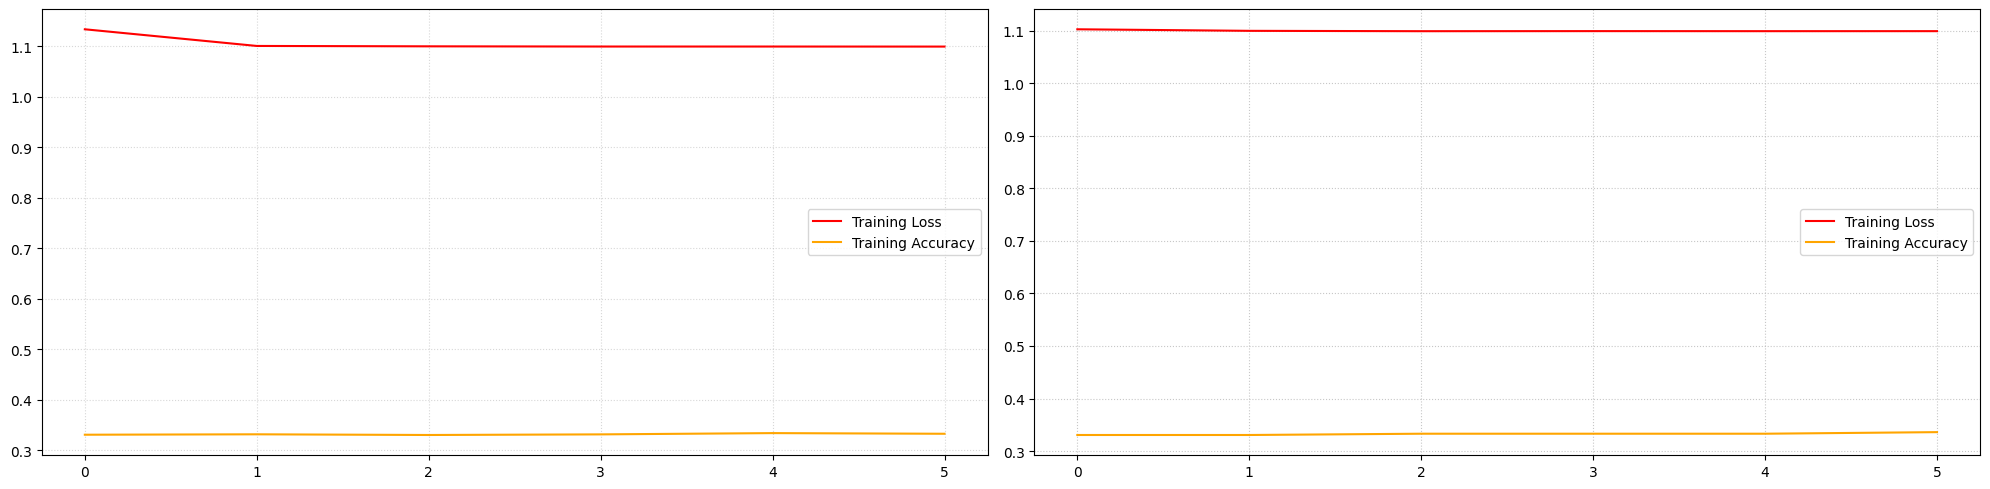

In [27]:
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.plot(training_loss, label='Training Loss', color='red')
plt.plot(training_accuracy, label='Training Accuracy', color='orange')
plt.legend()
plt.grid(True, alpha=0.5, linestyle=':')

plt.subplot(122)
plt.plot(val_loss, label='Training Loss', color='red')
plt.plot(val_accuracy, label='Training Accuracy', color='orange')
plt.legend()
plt.grid(True, alpha=0.7, linestyle=':')

plt.tight_layout()
plt.show()


In [28]:
print("=" * 50)

print(f"Best Validation Loss: {study.best_value:.4f}")
for i,j in study.best_params.items():
    print(f"    {i} : {j}")


print("=" * 50)

Best Validation Loss: 0.3361
    lr : 0.003565238350346592
    n_layers : 2
    neurons_0 : 161
    activation_fn_0 : relu
    initializer_0 : he_normal
    dropouts_0 : 0.0
    regularizer_0 : l1
    reg_rate_0 : 4.4035274744929245e-08
    neurons_1 : 81
    activation_fn_1 : tanh
    initializer_1 : he_normal
    dropouts_1 : 0.30000000000000004
    regularizer_1 : l2
    reg_rate_1 : 0.003051130900413476
    optimizer : adam


In [29]:
best_trial_num = study.best_trial.number
model = keras.models.load_model(f"model_trial_{best_trial_num}.keras")

y_pred = model.predict(x_test)

938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [30]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_classes = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes))

Accuracy: 0.3347333333333333
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     10017
           1       0.00      0.00      0.00      9941
           2       0.33      1.00      0.50     10042

    accuracy                           0.33     30000
   macro avg       0.11      0.33      0.17     30000
weighted avg       0.11      0.33      0.17     30000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
